# DS 5003, SP 2026 - Healthcare Data Science 

## *For Professor Christian Wernz, PhD, University of Virginia*

---

#### Team Members
* **Robert Ashby** | *University of Virginia, School of Data Science*  gsr3qz@virginia.edu
* **Xavier Colbert** | *University of Virginia, School of Data Science*  kxp3jj@virginia.edu
* **Alysa Pugmire** | *University of Virginia, School of Data Science*  amp3xs@virginia.edu
* **Jasmine Waller** | *University of Virginia, School of Data Science*  vwx5pn@virginia.edu

# CMS HAI Risk Prediction Pipeline
**Objective:** Develop a tool to determine if a facility is at risk of an HAI incident (HAI_1 through HAI_6) and identify which facility measures contribute most to correcting an "at-risk" status.

In [1]:
import sys
import numpy as np
import importlib
from pathlib import Path
import matplotlib.pyplot as plt

RANDOM_SEED = 42
# Set for numpy, pandas, and sklearn
np.random.seed(RANDOM_SEED)

# Add the 'code' folder to the system path so Python can find your scripts
if './code' not in sys.path:
    sys.path.append('./code')

print("Pipeline initialized. Ready to execute modules.")

Pipeline initialized. Ready to execute modules.


# 00: Data Retrieval
Self-healing check: Fetches CMS ZIP if data/raw is empty.

In [2]:
step_00 = importlib.import_module("00_download_data")
step_00.download_and_extract_cms_data()

[SKIP] Data already exists in D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\raw\cms_hospitals_jan2026


True

# 01: Data Import
Dynamically sweep the `data/raw/` directory and ingest ALL available CMS datasets.

In [3]:
# Import the module dynamically
step_01 = importlib.import_module("01_data_import")

# Execute the extraction function
raw_datasets = step_01.load_all_raw_data()

Scanning directory: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\raw\cms_hospitals_jan2026
--------------------------------------------------
Found 73 CSV files. Beginning import...

[LOADED] ASCQR_OAS_CAHPS_BY_ASC                   | Rows: 4452    | Cols: 30
[LOADED] ASCQR_OAS_CAHPS_NATIONAL                 | Rows: 1       | Cols: 21
[LOADED] ASCQR_OAS_CAHPS_STATE                    | Rows: 56      | Cols: 22
[LOADED] ASC_Facility                             | Rows: 5711    | Cols: 47
[LOADED] ASC_National                             | Rows: 1       | Cols: 37
[LOADED] ASC_State                                | Rows: 54      | Cols: 34
[LOADED] Birthing_Friendly_Hospitals_Geocoded     | Rows: 2265    | Cols: 7
[LOADED] CJR_Quality_Reporting_January_2026_Produ | Rows: 320     | Cols: 18
[LOADED] CMS_PSI_6_decimal_file                   | Rows: 52327   | Cols: 13
[LOADED] Complications_and_Deaths-Hospital        | Rows: 95780   | Cols: 18
[LOADED] Com

# 02: Data Interpretation
Profile all ingested raw datasets to evaluate row counts, memory usage, and the presence of joining keys (Facility ID). This generates the dataset inventory report.

In [4]:
# Import the module dynamically
step_02 = importlib.import_module("02_data_interpretation")

# Generate the profile and output the CSV to the interim folder
if raw_datasets:
    data_profile = step_02.generate_data_profile(raw_datasets)
    display(data_profile.head(10)) # Preview the top 10 largest files
else:
    print("No data available to profile.")


Analyzing datasets...

[SUCCESS] Data interpretation profile saved to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\interim\dataset_inventory_profile.csv
Review this CSV to determine which files to cull in Step 03.


,Dataset_Name,Row_Count,Column_Count,Has_Facility_ID,Memory_MB,Columns_List
20,HCAHPS-Hospital,325652,22,True,396.10,"Facility ID, Facility Name, Address, City/Town..."
23,Healthcare_Associated_Infections-Hospital,172404,15,True,145.91,"Facility ID, Facility Name, Address, City/Town..."
64,Timely_and_Effective_Care-Hospital,138129,16,True,126.30,"Facility ID, Facility Name, Address, City/Town..."
9,Complications_and_Deaths-Hospital,95780,18,True,95.69,"Facility ID, Facility Name, Address, City/Town..."
42,OQR_OAS_CAHPS_BY_HOSPITAL,92500,20,True,102.17,"Facility ID, Facility Name, Address, City/Town..."
67,Unplanned_Hospital_Visits-Hospital,67046,20,True,75.94,"Facility ID, Facility Name, Address, City/Town..."
38,Medicare_Hospital_Spending_by_Claim,63646,13,True,36.34,"Facility Name, Facility ID, State, Period, Cla..."
8,CMS_PSI_6_decimal_file,52327,13,True,35.20,"Facility ID, Facility Name, Address, City/Town..."
45,Outpatient_Imaging_Efficiency-Hospital,18500,14,True,13.33,"Facility ID, Facility Name, Address, City/Town..."
19,FY_2026_Hospital_Readmissions_Reduction_Progra...,18330,12,True,7.16,"Facility Name, Facility ID, State, Measure Nam..."


# 03: Data-Driven Ground Truth Construction

### The Standardized Infection Ratio (SIR)
The predictive target is anchored in the **CMS Standardized Infection Ratio (SIR)**. Unlike raw counts, the SIR is a risk-adjusted summary measure that compares the actual number of infections in a facility to the number of infections predicted based on national baseline data, adjusting for hospital size, type, and patient complexity.


### Risk-Adjusted Threshold as a Binary Label: HAI_at_risk
The ground truth outcome is the specific variable `HAI_at_risk`. A facility is assigned an HAI_at_risk value of 1 if any SIR measure exceeds 1.0. 

* HAI_at_risk = 1 indicates performance worse than the CMS risk-adjusted benchmark on at least one tracked HAI SIR measure.
* By using `HAI_at_risk` as the label, the model trains on standardized performance deviations relative to CMS benchmarks rather than arbitrary thresholds.


### Logic & Data Integrity via Inner Join
1. **Metric Narrowing:** The pipeline isolates SIR-specific measures (`HAI_1_SIR` through `HAI_6_SIR`) to maintain risk-adjusted consistency across different facility scales.
2. **Aggregation (Max Pooling):** Facilities are grouped by `Facility ID`. If a facility exceeds the CMS risk-adjusted benchmark (SIR > 1.0) in any tracked infection category, the `HAI_at_risk` label is set to 1. This identifies systemic vulnerability rather than isolated incidents.
3. **The Inner Join Constraint:** The master modeling set is constructed using an **Inner Join** between the `HAI_at_risk` labels and the general facility features:
    * **Integrity:** Training a supervised model requires known outcomes ($y$). 
    * **Logic:** Facilities with no reported HAI data are excluded because they provide no `HAI_at_risk` label to learn from. This ensures the "Predictive Drivers" are derived entirely from confirmed evidence.
    * **Result:** Every row in the final dataset represents a hospital with a confirmed `HAI_at_risk` status (the label) matched to its corresponding descriptive features (the predictors).

### Population and Distribution
The resulting distribution of the `HAI_at_risk` label represents the population of facilities actively participating in the national reporting program. This provides a data-driven baseline for machine learning algorithms to discover the specific care-process features and metrics that correlate with a facility's "At Risk" status.

In [5]:
step_03 = importlib.import_module("03_data_processing")

if 'raw_datasets' in locals():
    master_data = step_03.build_target_and_master(raw_datasets)
    display(master_data.head())

--- 03 Processing Complete ---
Total Facilities: 4789
At Risk Count:   1432


,Facility ID,HAI_at_risk,Hospital Type,Hospital Ownership,Hospital overall rating
0,010001,0,Acute Care Hospitals,Government - Hospital District or Authority,4
1,010005,1,Acute Care Hospitals,Government - Hospital District or Authority,3
2,010006,0,Acute Care Hospitals,Proprietary,2
3,010007,0,Acute Care Hospitals,Voluntary non-profit - Private,1
4,010008,0,Acute Care Hospitals,Proprietary,Not Available


# 04: Exploratory Data Analysis
Visualizing the risk distribution across the dataset.

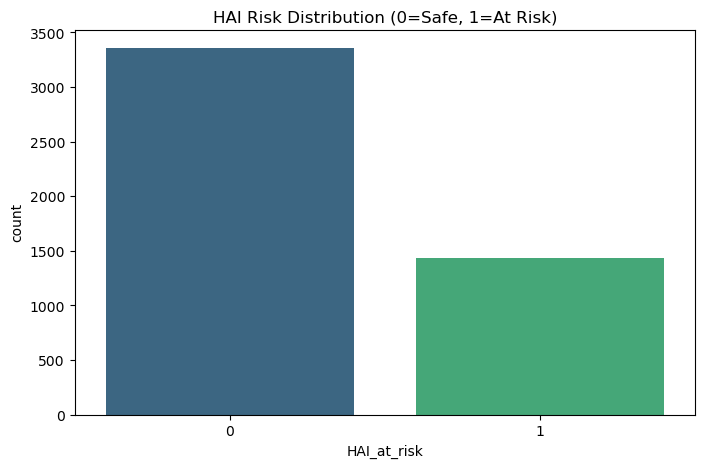

In [6]:
step_04 = importlib.import_module("04_data_analysis")

if 'master_data' in locals():
    step_04.run_eda()

In [7]:
FRIENDLY_LABELS = {
    "PSI_90": "Serious complications composite (PSI-90)",
    "PSI_03": "Pressure ulcer rate",
    "PSI_06": "Iatrogenic pneumothorax rate",
    "PSI_09": "Postoperative hemorrhage or hematoma rate",
    "PSI_10": "Postoperative kidney or metabolic complication rate",
    "PSI_11": "Postoperative respiratory failure rate",
    "PSI_12": "Postoperative pulmonary embolism or DVT rate",
    "PSI_13": "Postoperative sepsis rate",
    "PSI_14": "Postoperative wound dehiscence rate",
    "PSI_15": "Accidental puncture or laceration rate",
    "Hybrid_HWM": "Hospital-wide all-cause mortality rate",
    "Hybrid_HWR": "Hospital-wide all-cause readmission rate",
    "MORT_30_COPD": "30-day mortality rate for COPD patients",
    "MORT_30_HF": "30-day mortality rate for heart failure patients",
    "MORT_30_PN": "30-day mortality rate for pneumonia patients",
    "OP_18a": "ED time before departure, all patients",
    "OP_18b": "ED time before departure, excluding transfers and psych patients",
    "OP_18c": "ED time before discharge home, psych/mental health patients",
    "OP_22": "Percent leaving ED before being seen",
    "OP_23": "Percent receiving brain scan results within 45 minutes for stroke symptoms",
    "SEP_1": "Sepsis and septic shock bundle performance",
    "SEP_SH_3HR": "Septic shock 3-hour bundle performance",
    "SEP_SH_6HR": "Septic shock 6-hour bundle performance",
    "SEV_SEP_3HR": "Severe sepsis 3-hour bundle performance",
    "SEV_SEP_6HR": "Severe sepsis 6-hour bundle performance",
    "EDAC_30_HF": "Excess days in acute care after heart failure hospitalization",
    "EDAC_30_PN": "Excess days in acute care after pneumonia hospitalization",
    "READM_30_COPD": "30-day readmission rate for COPD patients",
    "READM_30_HF": "30-day readmission rate for heart failure patients",
    "READM_30_PN": "30-day readmission rate for pneumonia patients",
    "OP_32": "Unplanned hospital visits after outpatient colonoscopy",
    "OP_36": "Ratio of unplanned hospital visits after outpatient surgery",
    "MSPB-1_x": "Medicare spending per beneficiary",
    "MSPB-1_y": "Medicare spending per beneficiary"
}

In [8]:
def relabel_feature(name):
    if name.startswith("num__"):
        raw = name.replace("num__", "")
        return FRIENDLY_LABELS.get(raw, raw)

    if name.startswith("cat__"):
        raw = name.replace("cat__", "")
        raw = raw.replace("_", " = ", 1)
        return raw

    return FRIENDLY_LABELS.get(name, name)

# 05: Dynamic Feature Discovery and Selection

### 1. The Master Anchor
The process begins with the **Master Modeling Set** (4,789 facilities). By using this as the anchor, the script ensures that every potential predictor is linked to a facility with a known `HAI_at_risk` label.

### 2. Automated File Screening
Instead of manually selecting files, the logic scans all available datasets and applies a **Statistical Gatekeeper** to ensure high-quality inputs:
* **Identity Check:** A file must contain a `Facility ID` to be eligible for the join.
* **Population Overlap (50% Threshold):** Only files that contain data for at least 50% of the target facilities are processed. This automatically filters out noise from specialized datasets or state-level summaries that do not provide enough context for the whole population.

### 3. Structural Reshaping (Long-to-Wide)
CMS data is natively stored in a "Long" format where each measurement occupies a row. Machine learning requires "Wide" data where each row is a unique observation (hospital) and each column is a feature (predictor).
* **Numeric Identification:** The script locates the specific numeric measurement column (e.g., `Score`, `Value`, or `HCAHPS Linear Mean Score`).
* **Pivoting:** The `Measure ID` is transformed into a column header, and the numeric result becomes the cell value. 

### 4. Density-Based Feature Selection
To prevent the model from overfitting on sparse data or "learning from noise," a **Sparsity Filter** is applied to the individual columns:
* If a specific measure (e.g., `MORT_30_PN`) is missing for more than 50% of the hospitals in the modeling set, that feature is discarded.
* This ensures the resulting features are robust, high-density predictors that exist across the majority of the population.

### 5. Final Synthesis and Imputation
The disparate data points—ranging from clinical outcomes to patient satisfaction—are merged via a **Left Join**:
* **Integrity:** The 4,789 facilities are preserved as the primary population.
* **Model Readiness:** Remaining missing values are imputed using the **column median**. This provides a stable baseline for algorithms like XGBoost or Random Forest, ensuring that the "Predictive Drivers" are derived from the central tendency of the evidence.

In [9]:
step_05 = importlib.import_module("05_feature_identification")

if 'raw_datasets' in locals():
    final_df = step_05.mine_features(
        raw_datasets,
        exclude_files=["Healthcare_Associated_Infections-Hospital"]
    )
    display(final_df.head())

Targeting predictors for 4789 facilities...
[DATA DISCOVERED] Complications_and_Deaths-Hospital: Added 15 features.
[SKIP - EXCLUDED SOURCE] Healthcare_Associated_Infections-Hospital
[DATA DISCOVERED] HOSPITAL_QUARTERLY_MSPB_6_DECIMALS: Added 1 features.
[DATA DISCOVERED] Medicare_Hospital_Spending_Per_Patient-Hospital: Added 1 features.
[DATA DISCOVERED] Outpatient_Imaging_Efficiency-Hospital: Added 2 features.
[DATA DISCOVERED] Timely_and_Effective_Care-Hospital: Added 11 features.
[DATA DISCOVERED] Unplanned_Hospital_Visits-Hospital: Added 8 features.
------------------------------
[SUCCESS] Final Feature Set Shape: (4789, 43)
[INFO] Included feature sources: ['Complications_and_Deaths-Hospital', 'HOSPITAL_QUARTERLY_MSPB_6_DECIMALS', 'Medicare_Hospital_Spending_Per_Patient-Hospital', 'Outpatient_Imaging_Efficiency-Hospital', 'Timely_and_Effective_Care-Hospital', 'Unplanned_Hospital_Visits-Hospital']
[INFO] Excluded feature sources: ['Healthcare_Associated_Infections-Hospital']


,Facility ID,HAI_at_risk,Hospital Type,Hospital Ownership,Hospital overall rating,Hybrid_HWM,MORT_30_COPD,MORT_30_HF,MORT_30_PN,PSI_03,...,SEV_SEP_3HR,SEV_SEP_6HR,EDAC_30_HF,EDAC_30_PN,Hybrid_HWR,OP_32,OP_36,READM_30_COPD,READM_30_HF,READM_30_PN
0,010001,0,Acute Care Hospitals,Government - Hospital District or Authority,4,4.5,9.4,10.2,18.4,0.13,...,78.0,97.0,-1.1,17.4,15.1,12.7,1.1,18.0,20.1,16.0
1,010005,1,Acute Care Hospitals,Government - Hospital District or Authority,3,4.6,8.9,14.1,21.2,0.33,...,85.0,99.0,12.2,-17.2,13.3,13.0,0.9,17.1,19.8,13.9
2,010006,0,Acute Care Hospitals,Proprietary,2,5.2,8.7,12.5,19.6,0.55,...,78.0,96.0,-4.7,-0.9,15.9,11.1,1.2,19.1,19.5,15.7
3,010007,0,Acute Care Hospitals,Voluntary non-profit - Private,1,4.8,11.2,13.4,25.4,0.54,...,62.0,94.0,77.9,29.8,15.4,12.5,1.0,18.6,20.9,16.5
4,010008,0,Acute Care Hospitals,Proprietary,Not Available,4.3,8.7,11.5,15.0,0.60,...,81.0,94.0,2.6,-8.9,14.7,12.7,1.0,18.1,19.6,16.0


## Data Split and Cross-Validation

In [10]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
 
# 1. Setup the Stratified 5-Fold with Shuffling
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
# 2. Separate Features and Target
X = final_df.drop('HAI_at_risk', axis=1)
y = final_df['HAI_at_risk']
 
# 3. Execution Loop
fold_results = []
 
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Verification: Check if the ratio of 'at_risk' remains consistent
    train_ratio = y_train.mean()
    test_ratio = y_test.mean()
    
    print(f"--- Fold {fold + 1} ---")
    print(f"Train At-Risk Ratio: {train_ratio:.2%}, Test At-Risk Ratio: {test_ratio:.2%}")
    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

--- Fold 1 ---
Train At-Risk Ratio: 29.91%, Test At-Risk Ratio: 29.85%
Train size: 3831, Test size: 958
--- Fold 2 ---
Train At-Risk Ratio: 29.91%, Test At-Risk Ratio: 29.85%
Train size: 3831, Test size: 958
--- Fold 3 ---
Train At-Risk Ratio: 29.89%, Test At-Risk Ratio: 29.96%
Train size: 3831, Test size: 958
--- Fold 4 ---
Train At-Risk Ratio: 29.89%, Test At-Risk Ratio: 29.96%
Train size: 3831, Test size: 958
--- Fold 5 ---
Train At-Risk Ratio: 29.91%, Test At-Risk Ratio: 29.89%
Train size: 3832, Test size: 957


## Modeling Setup

The next stage builds a consistent modeling workflow across Logistic Regression, Random Forest, and XGBoost. A held-out test split is created for final comparison, while stratified 5-fold cross-validation is retained inside the training data for hyperparameter tuning. Separate preprocessing pipelines are used for linear and tree-based models so that categorical variables, missing values, and feature scaling are handled appropriately.

In [11]:
# Modeling imports
import importlib
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [12]:
# Train/test split for final held-out evaluation
X = final_df.drop(columns=['HAI_at_risk',
                           'Facility ID', 
                           'Hospital overall rating',
                           'Hospital Type',
                           'Hospital Ownership'
                           ]
                )
y = final_df['HAI_at_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows: {X_test.shape[0]}")
print(f"Train at-risk rate: {y_train.mean():.2%}")
print(f"Test at-risk rate: {y_test.mean():.2%}")

# Inner CV used for model tuning on the training set only
cv_inner = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

# Identify column types
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Preprocessing for Logistic Regression
numeric_transformer_scaled = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess_logreg = ColumnTransformer([
    ('num', numeric_transformer_scaled, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Preprocessing for Random Forest and XGBoost
numeric_transformer_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocess_tree = ColumnTransformer([
    ('num', numeric_transformer_tree, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Class-balance settings
class_weight_balanced = 'balanced'
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"scale_pos_weight: {scale_pos_weight:.3f}")

Training rows: 3831
Test rows: 958
Train at-risk rate: 29.91%
Test at-risk rate: 29.85%
Numeric features: 38
Categorical features: 0
scale_pos_weight: 2.343


# 06: Logistic Regression

Logistic Regression provides the most interpretable baseline in the modeling suite. Because it is a linear model, the preprocessing pipeline includes both imputation and feature scaling. Hyperparameters are tuned with stratified 5-fold cross-validation on the training set, and final performance is reserved for the held-out test set.

In [13]:
# Step 06: Logistic Regression
step_06 = importlib.import_module("06_model_logreg")
importlib.reload(step_06)

logreg_cv, logreg_pipe, logreg_params = step_06.run_logreg_model(
    preprocess=preprocess_logreg,
    cv=cv_inner,
    Xtrain=X_train,
    ytrain=y_train,
    penalty='elasticnet',
    class_weight=class_weight_balanced,
    random_seed=RANDOM_SEED,
    n_iter=25,
    scoring='roc_auc',
    n_jobs=-1
)

logreg_best = logreg_cv.best_estimator_

print("Best Logistic Regression CV ROC-AUC:", round(logreg_cv.best_score_, 4))
print("Best Logistic Regression Params:")
print(logreg_cv.best_params_)

logreg_results = pd.DataFrame(logreg_cv.cv_results_)
logreg_summary_cols = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'param_logreg__C'
]

if 'param_logreg__l1_ratio' in logreg_results.columns:
    logreg_summary_cols.append('param_logreg__l1_ratio')

display(
    logreg_results[logreg_summary_cols]
    .sort_values('rank_test_score')
    .head(10)
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\rjaxb\miniconda3\envs\cms-hai-risk-prediction\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Logistic Regression CV ROC-AUC: 0.7998
Best Logistic Regression Params:
{'logreg__C': np.float64(456.6054873446131), 'logreg__l1_ratio': np.float64(0.5555555555555556)}


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_logreg__C,param_logreg__l1_ratio
7,1,0.799785,0.011557,0.813302,456.605487,0.555556
5,2,0.799782,0.011541,0.813290,46.193474,0.555556
15,3,0.799782,0.011556,0.813302,757.745305,0.666667
18,4,0.799772,0.011552,0.813300,5309.532269,0.111111
1,5,0.799756,0.011556,0.813265,6.155564,0.666667
22,6,0.799738,0.011523,0.813286,7.585309,0.777778
9,7,0.799719,0.011499,0.813277,8.706670,1.000000
14,8,0.799676,0.011790,0.813215,5.486767,0.222222
10,9,0.799353,0.012018,0.813080,1.577798,0.888889
2,10,0.795853,0.012410,0.809555,0.368691,0.666667


# 07: Random Forest

Random Forest provides a nonlinear ensemble baseline that can capture interactions and threshold effects without requiring scaled numeric inputs. The same held-out evaluation framework is preserved so that its performance can be compared directly against Logistic Regression and XGBoost.

In [14]:
# Step 07: Random Forest
step_07 = importlib.import_module("07_model_randforest")
importlib.reload(step_07)

rf_cv, rf_pipe, rf_params = step_07.run_rf_model(
    preprocess=preprocess_tree,
    cv=cv_inner,
    Xtrain=X_train,
    ytrain=y_train,
    class_weight=class_weight_balanced,
    random_seed=RANDOM_SEED,
    n_iter=25,
    scoring='roc_auc',
    n_jobs=-1
)

rf_best = rf_cv.best_estimator_

print("Best Random Forest CV ROC-AUC:", round(rf_cv.best_score_, 4))
print("Best Random Forest Params:")
print(rf_cv.best_params_)

rf_results = pd.DataFrame(rf_cv.cv_results_)
rf_summary_cols = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'param_rf__n_estimators',
    'param_rf__max_depth',
    'param_rf__min_samples_split',
    'param_rf__min_samples_leaf',
    'param_rf__max_features'
]

display(
    rf_results[rf_summary_cols]
    .sort_values('rank_test_score')
    .head(10)
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Random Forest CV ROC-AUC: 0.8393
Best Random Forest Params:
{'rf__max_depth': 30, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 8, 'rf__n_estimators': 363}


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_rf__n_estimators,param_rf__max_depth,param_rf__min_samples_split,param_rf__min_samples_leaf,param_rf__max_features
10,1,0.839346,0.006997,0.990247,363,30,8,4,log2
5,2,0.838495,0.005786,0.982288,148,20,10,5,log2
3,3,0.838398,0.007960,0.966334,443,10,3,5,log2
7,4,0.837908,0.009635,0.996545,406,20,6,3,sqrt
14,5,0.837689,0.007296,0.986485,289,20,10,4,log2
0,6,0.837371,0.008336,0.992898,288,20,9,3,sqrt
4,7,0.837138,0.011953,0.997817,260,20,6,2,log2
9,8,0.837094,0.009114,0.993924,445,20,10,2,log2
24,9,0.836766,0.007096,0.967805,354,10,8,5,sqrt
12,10,0.836742,0.008369,0.998272,409,20,5,2,log2


# 08: XGBoost

XGBoost serves as the strongest gradient-boosted tree baseline in the current workflow. It can accommodate nonlinear relationships and complex feature interactions while still using the same held-out evaluation design. The positive-class weight is scaled from the training data to help address class imbalance during fitting.

In [15]:
# Step 08: XGBoost
step_08 = importlib.import_module("08_model_xgboost")
importlib.reload(step_08)

xgb_cv, xgb_pipe, xgb_params = step_08.run_xgb_model(
    preprocess=preprocess_tree,
    cv=cv_inner,
    Xtrain=X_train,
    ytrain=y_train,
    scale_pos_weight=scale_pos_weight,
    random_seed=RANDOM_SEED,
    n_iter=25,
    scoring='roc_auc',
    n_jobs=-1
)

xgb_best = xgb_cv.best_estimator_

print("Best XGBoost CV ROC-AUC:", round(xgb_cv.best_score_, 4))
print("Best XGBoost Params:")
print(xgb_cv.best_params_)

xgb_results = pd.DataFrame(xgb_cv.cv_results_)
xgb_summary_cols = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'param_xgb__n_estimators',
    'param_xgb__learning_rate',
    'param_xgb__max_depth',
    'param_xgb__min_child_weight',
    'param_xgb__subsample',
    'param_xgb__colsample_bytree'
]

display(
    xgb_results[xgb_summary_cols]
    .sort_values('rank_test_score')
    .head(10)
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best XGBoost CV ROC-AUC: 0.8369
Best XGBoost Params:
{'xgb__colsample_bytree': np.float64(0.6), 'xgb__learning_rate': np.float64(0.01054622102066491), 'xgb__max_depth': 3, 'xgb__min_child_weight': 1, 'xgb__n_estimators': 235, 'xgb__subsample': np.float64(0.8)}


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_xgb__n_estimators,param_xgb__learning_rate,param_xgb__max_depth,param_xgb__min_child_weight,param_xgb__subsample,param_xgb__colsample_bytree
14,1,0.836928,0.008724,0.879095,235,0.010546,3,1,0.8,0.6
1,2,0.835780,0.007601,0.938863,199,0.014050,5,5,0.8,0.8
6,3,0.835718,0.007612,0.981473,415,0.012476,6,1,0.7,0.6
24,4,0.834196,0.007818,0.976258,227,0.021021,6,3,0.7,0.9
8,5,0.832813,0.007839,0.983215,305,0.015145,7,3,0.6,0.9
20,6,0.832112,0.009078,0.971699,151,0.044561,5,1,1.0,0.7
13,7,0.831917,0.010146,0.909248,114,0.063333,3,5,1.0,0.9
17,8,0.831844,0.007670,0.995739,198,0.030816,9,5,0.9,0.9
10,9,0.830876,0.010804,0.998173,317,0.018752,9,2,0.9,0.9
4,10,0.829851,0.010749,0.999500,287,0.059588,9,2,0.8,0.6


# 09 Held-Out Model Evaluation

The three tuned models are compared on the same held-out test set using ROC-AUC, average precision, balanced accuracy, precision, recall, F1, and Matthews Correlation Coefficient. This keeps model selection and final evaluation separate and provides a clearer comparison than accuracy alone.

In [16]:
# Helper for held-out evaluation
def evaluate_classifier(model, X_eval, y_eval, model_name, threshold=0.50):
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    results = {
        'model': model_name,
        'roc_auc': roc_auc_score(y_eval, y_prob),
        'avg_precision': average_precision_score(y_eval, y_prob),
        'balanced_accuracy': balanced_accuracy_score(y_eval, y_pred),
        'precision': precision_score(y_eval, y_pred, zero_division=0),
        'recall': recall_score(y_eval, y_pred, zero_division=0),
        'f1': f1_score(y_eval, y_pred, zero_division=0),
        'mcc': matthews_corrcoef(y_eval, y_pred)
    }

    print(f"\n===== {model_name} =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_eval, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_eval, y_pred, zero_division=0))

    return results


model_results = []
model_results.append(evaluate_classifier(logreg_best, X_test, y_test, "Logistic Regression"))
model_results.append(evaluate_classifier(rf_best, X_test, y_test, "Random Forest"))
model_results.append(evaluate_classifier(xgb_best, X_test, y_test, "XGBoost"))

results_df = pd.DataFrame(model_results).sort_values(by='roc_auc', ascending=False)
display(results_df)


===== Logistic Regression =====
Confusion Matrix:
[[501 171]
 [ 70 216]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81       672
           1       0.56      0.76      0.64       286

    accuracy                           0.75       958
   macro avg       0.72      0.75      0.72       958
weighted avg       0.78      0.75      0.76       958


===== Random Forest =====
Confusion Matrix:
[[538 134]
 [ 70 216]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       672
           1       0.62      0.76      0.68       286

    accuracy                           0.79       958
   macro avg       0.75      0.78      0.76       958
weighted avg       0.80      0.79      0.79       958


===== XGBoost =====
Confusion Matrix:
[[485 187]
 [ 43 243]]

Classification Report:
              precision    recall  f1-score   support

           0   

,model,roc_auc,avg_precision,balanced_accuracy,precision,recall,f1,mcc
2,XGBoost,0.854120,0.670997,0.785688,0.565116,0.849650,0.678771,0.525701
1,Random Forest,0.853105,0.656745,0.777920,0.617143,0.755245,0.679245,0.528240
0,Logistic Regression,0.810335,0.608280,0.750390,0.558140,0.755245,0.641902,0.467026


In [17]:
step_09 = importlib.import_module("09_evaluator")
importlib.reload(step_09)

<module '09_evaluator' from 'd:\\Documents\\School\\UVA\\MSDS\\DS 5003\\Project\\GitHub\\cms-hai-risk-prediction\\code\\09_evaluator.py'>

In [18]:
models = {
    "Logistic Regression": logreg_best,
    "Random Forest": rf_best,
    "XGBoost": xgb_best
}

results_df = step_09.compare_models(
    models=models,
    X_eval=X_test,
    y_eval=y_test,
    threshold=0.50,
    save_csv=True
)

display(results_df)


===== Logistic Regression =====
Threshold: 0.50
Confusion Matrix:
[[501 171]
 [ 70 216]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81       672
           1       0.56      0.76      0.64       286

    accuracy                           0.75       958
   macro avg       0.72      0.75      0.72       958
weighted avg       0.78      0.75      0.76       958


===== Random Forest =====
Threshold: 0.50
Confusion Matrix:
[[538 134]
 [ 70 216]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       672
           1       0.62      0.76      0.68       286

    accuracy                           0.79       958
   macro avg       0.75      0.78      0.76       958
weighted avg       0.80      0.79      0.79       958


===== XGBoost =====
Threshold: 0.50
Confusion Matrix:
[[485 187]
 [ 43 243]]

Classification Report:
              precisio

,model,threshold,roc_auc,avg_precision,balanced_accuracy,precision,recall,f1,mcc,tn,fp,fn,tp
0,XGBoost,0.5,0.854120,0.670997,0.785688,0.565116,0.849650,0.678771,0.525701,485,187,43,243
1,Random Forest,0.5,0.853105,0.656745,0.777920,0.617143,0.755245,0.679245,0.528240,538,134,70,216
2,Logistic Regression,0.5,0.810335,0.608280,0.750390,0.558140,0.755245,0.641902,0.467026,501,171,70,216


In [19]:
rf_eval = step_09.evaluate_classifier(
    model=rf_best,
    X_eval=X_test,
    y_eval=y_test,
    model_name="Random Forest",
    threshold=0.50,
    save_confusion_plot=True,
    normalize_confusion="true"
)


===== Random Forest =====
Threshold: 0.50
Confusion Matrix:
[[538 134]
 [ 70 216]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       672
           1       0.62      0.76      0.68       286

    accuracy                           0.79       958
   macro avg       0.75      0.78      0.76       958
weighted avg       0.80      0.79      0.79       958



In [20]:
rf_thresholds = step_09.threshold_sweep(
    model=rf_best,
    X_eval=X_test,
    y_eval=y_test,
    model_name="Random Forest",
    save_csv=True
)

display(rf_thresholds.sort_values("f1", ascending=False).head(10))

[SUCCESS] Saved threshold sweep table to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\random_forest_threshold_sweep.csv


,model,threshold,roc_auc,avg_precision,balanced_accuracy,precision,recall,f1,mcc,tn,fp,fn,tp
7,Random Forest,0.45,0.853105,0.656745,0.784575,0.585427,0.814685,0.681287,0.528516,507,165,53,233
8,Random Forest,0.50,0.853105,0.656745,0.777920,0.617143,0.755245,0.679245,0.528240,538,134,70,216
6,Random Forest,0.40,0.853105,0.656745,0.781188,0.563380,0.839161,0.674157,0.517885,486,186,46,240
5,Random Forest,0.35,0.853105,0.656745,0.780032,0.547672,0.863636,0.670285,0.513468,468,204,39,247
9,Random Forest,0.55,0.853105,0.656745,0.758544,0.645485,0.674825,0.659829,0.510685,566,106,93,193
4,Random Forest,0.30,0.853105,0.656745,0.765968,0.516327,0.884615,0.652062,0.486975,435,237,33,253
3,Random Forest,0.25,0.853105,0.656745,0.761353,0.499044,0.912587,0.645241,0.480430,410,262,25,261
2,Random Forest,0.20,0.853105,0.656745,0.745057,0.472566,0.933566,0.627497,0.455978,374,298,19,267
1,Random Forest,0.15,0.853105,0.656745,0.727049,0.446429,0.961538,0.609756,0.433724,331,341,11,275
10,Random Forest,0.60,0.853105,0.656745,0.716664,0.679825,0.541958,0.603113,0.465645,599,73,131,155


[SUCCESS] Saved ROC curve plot to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\roc_curves.png
[SUCCESS] Saved precision-recall plot to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\precision_recall_curves.png


(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Precision-Recall Curves'}, xlabel='Recall', ylabel='Precision'>)

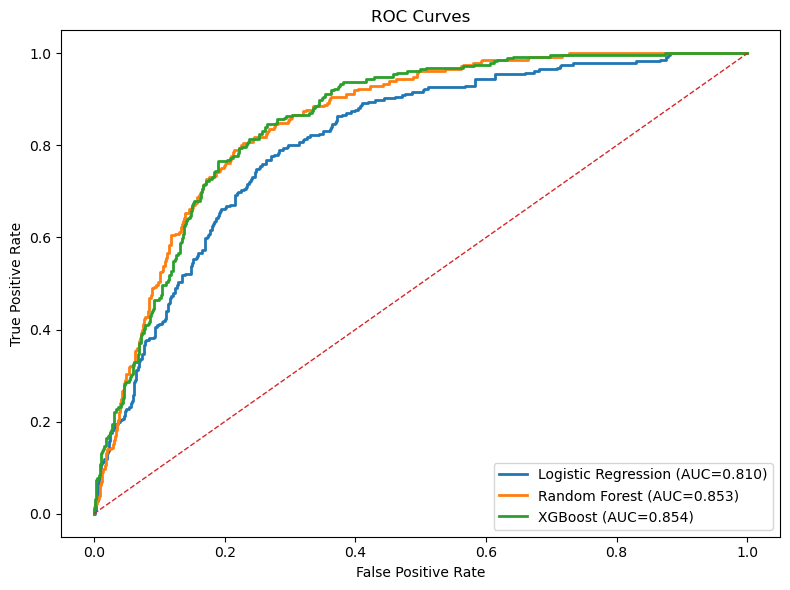

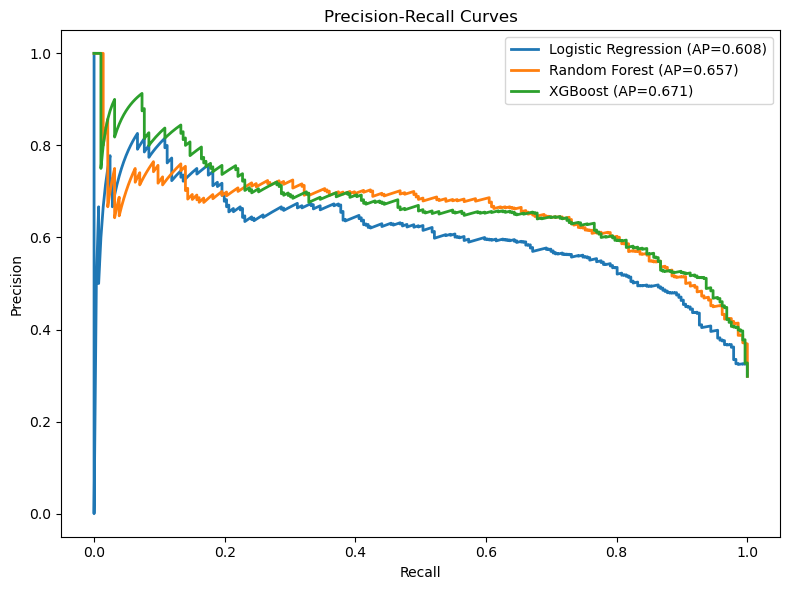

In [21]:
step_09.plot_roc_curves(models, X_test, y_test, save_plot=True)
step_09.plot_precision_recall_curves(models, X_test, y_test, save_plot=True)

In [22]:
logreg_imp = step_09.extract_logreg_importance(
    fitted_pipeline=logreg_best,
    top_n=20,
    save_csv=True
)

display(logreg_imp.head(20))

[SUCCESS] Saved Logistic Regression importance table to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\logreg_feature_importance.csv


,feature,coefficient,abs_coefficient,odds_ratio
0,num__PSI_90,-5.551593,5.551593,0.003881
1,num__PSI_03,4.375981,4.375981,79.517843
2,num__OP_18b,3.052698,3.052698,21.172387
3,num__OP_18a,-2.363478,2.363478,0.094092
4,num__PSI_11,2.278107,2.278107,9.758193
5,num__PSI_13,1.106376,1.106376,3.023381
6,num__PSI_12,0.884370,0.884370,2.421459
7,num__PSI_10,0.370370,0.370370,1.448270
8,num__MSPB-1_y,0.362119,0.362119,1.436370
9,num__MSPB-1_x,-0.295564,0.295564,0.744112


In [23]:
rf_imp = step_09.extract_tree_importance(
    fitted_pipeline=rf_best,
    model_step_name="rf",
    top_n=20,
    save_csv=True
)

xgb_imp = step_09.extract_tree_importance(
    fitted_pipeline=xgb_best,
    model_step_name="xgb",
    top_n=20,
    save_csv=True
)

display(rf_imp.head(20))
display(xgb_imp.head(20))

[SUCCESS] Saved rf importance table to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\rf_feature_importance.csv
[SUCCESS] Saved xgb importance table to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\xgb_feature_importance.csv


,feature,importance
0,num__OP_18b,0.083008
1,num__OP_18a,0.066085
2,num__PSI_14,0.058283
3,num__PSI_15,0.049292
4,num__PSI_13,0.045279
5,num__PSI_09,0.040671
6,num__PSI_12,0.036945
7,num__PSI_10,0.036324
8,num__PSI_06,0.035933
9,num__PSI_11,0.035047


,feature,importance
0,num__OP_18b,0.139196
1,num__OP_18a,0.106380
2,num__PSI_15,0.078270
3,num__PSI_08,0.067186
4,num__PSI_14,0.064369
5,num__PSI_12,0.040288
6,num__PSI_11,0.037413
7,num__SEP_SH_3HR,0.036220
8,num__PSI_10,0.032752
9,num__PSI_09,0.032139


[SUCCESS] Saved feature importance plot to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\random_forest_top_features.png
[SUCCESS] Saved feature importance plot to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\logistic_regression_top_features.png


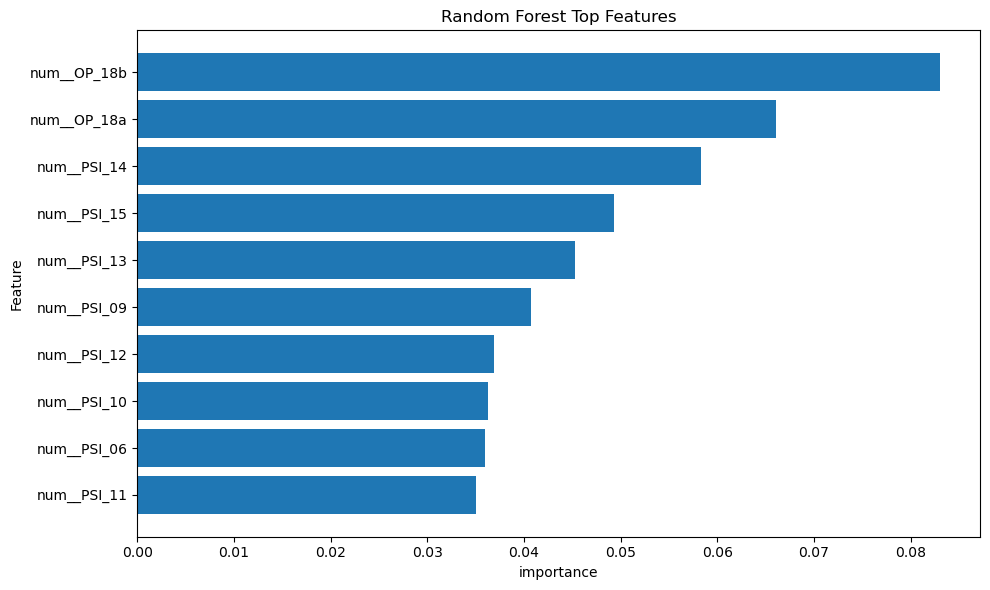

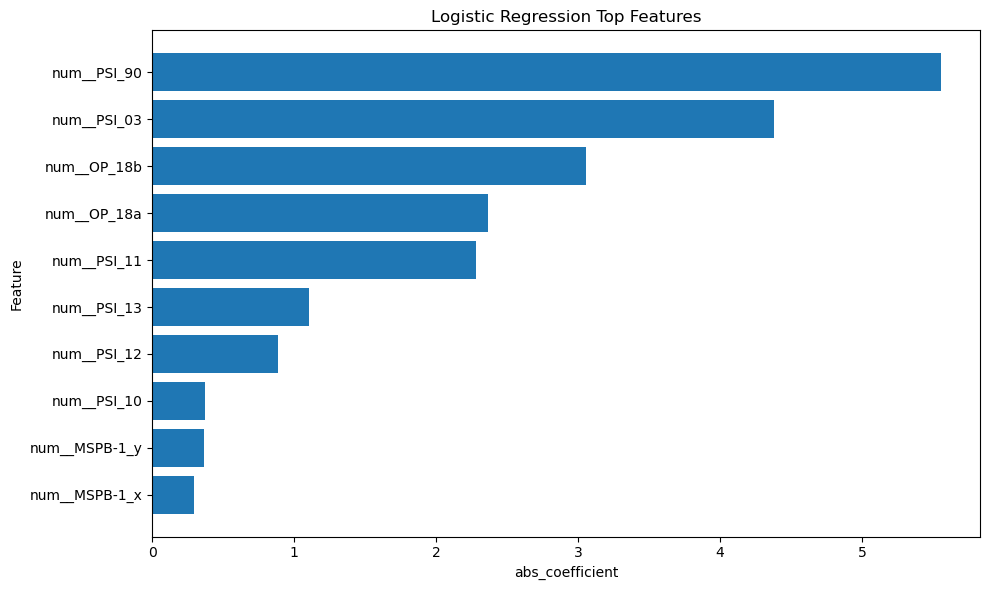

In [24]:
step_09.plot_top_features(
    importance_df=rf_imp,
    feature_col="feature",
    value_col="importance",
    title="Random Forest Top Features",
    top_n=10,
    save_plot=True
)

step_09.plot_top_features(
    importance_df=logreg_imp,
    feature_col="feature",
    value_col="abs_coefficient",
    title="Logistic Regression Top Features",
    top_n=10,
    save_plot=True
)

plt.show()

# Meeting Discussion 3/27/26

Items to address:

- confusion matrices/code base: Robert
- Tableau visualizations: Alysa
- update data dictionary: Alysa
- start drafting report : Jasmine
    - 3-4 articles framing this as a problem (short lit review)
- start powerpoint : Xavier

target audience is hospital leadership
